# Cat vs Dog Image Classification Using CNN

This project develops a Convolutional Neural Network (CNN) to classify images into two categories: **Cat** and **Dog**.

The model is trained using a dataset containing cat and dog images. TensorFlow and Keras are used to build and train the CNN model.

The project includes data loading, image preprocessing, CNN model development, data augmentation, model training, evaluation, confusion matrix, classification report, and testing the trained model on new images.

## 1. Imports and Environment Setup

The first step is to import the required Python libraries.

- **TensorFlow** is used to build and train the CNN model.
- **Keras** provides tools for creating neural network layers and loading images.
- **NumPy** is used for numerical operations and manipulating image arrays.
- **Matplotlib** is used to visualize images and training results.
- **OS** is used to work with folders and files.

The TensorFlow version and available GPU are also checked to understand the computing environment.

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
Keras: 3.13.2
GPU: []


## 2. Google Drive Connection and Dataset

Google Drive is connected to Google Colab so that the dataset stored in Drive can be accessed directly.

The dataset is stored as a ZIP file. After connecting Google Drive, the required dataset files are located and extracted into the Colab environment.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Check Dataset Files

The contents of the `Datas` folder are displayed to verify that the cat and dog dataset ZIP file is available before extraction.

In [4]:
import os

print(os.listdir('/content/drive/MyDrive/Datas'))

['cat_dog_dataset.zip']


## Extract the Dataset

The dataset is stored in a ZIP file, so it needs to be extracted before the images can be used for training.

The `zipfile` library is used to open the ZIP file and extract all of its contents into the specified directory.

After extraction, the dataset will contain separate folders for the training and testing images.

In [5]:
import zipfile

zip_path = '/content/drive/MyDrive/Datas/cat_dog_dataset.zip'
extract_path = '/content/cat_dog_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


## 2. Load and Inspect the Dataset

After extracting the dataset, we first check the contents of the extracted dataset folder.

This helps us confirm that the dataset was extracted successfully and identify the folders available inside it.

In [6]:
import os

print(os.listdir('/content/cat_dog_dataset'))

['training_set', 'test_set']


## Loading the Dataset

In this step, we load the **Cat and Dog image dataset** from the training and testing directories using `image_dataset_from_directory()`.

The images are resized to **150 × 150 pixels** and grouped into batches of **32 images**. The dataset is divided into **training data** for learning the model and **testing data** for evaluating its performance.


In [7]:
from tensorflow.keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    '/content/cat_dog_dataset/training_set',
    image_size=(150, 150),
    batch_size=32
)

test_ds = image_dataset_from_directory(
    '/content/cat_dog_dataset/test_set',
    image_size=(150, 150),
    batch_size=32
)

Found 8005 files belonging to 1 classes.
Found 2023 files belonging to 1 classes.


Checking the Dataset Folders

In this step, we use the os module to check the contents of the training dataset directory. This helps us verify that the required class folders.

In [8]:
import os

print(os.listdir('/content/cat_dog_dataset/training_set'))

['training_set']


## Loading the Training and Testing Dataset

In this step, we load the **training and testing images** from their respective directories using `image_dataset_from_directory()`.

The images are resized to **150 × 150 pixels** and divided into batches of **32 images**. The output confirms that the dataset contains **8,005 training images** and **2,023 testing images**, belonging to **2 classes: Cat and Dog**.


In [9]:
from tensorflow.keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    '/content/cat_dog_dataset/training_set/training_set',
    image_size=(150, 150),
    batch_size=32
)

test_ds = image_dataset_from_directory(
    '/content/cat_dog_dataset/test_set/test_set',
    image_size=(150, 150),
    batch_size=32
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


## Checking the Class Names

In this step, we check the class names assigned to the dataset. This helps us confirm the two categories used for classification, **Cat** and **Dog**, and their order in the dataset.


In [10]:
print(train_ds.class_names)

['cats', 'dogs']


## Building the CNN Model

This code creates a Convolutional Neural Network (CNN) for classifying images into two classes: **Cat and Dog**. The `Input` layer defines the image size as 150×150 pixels with 3 color channels (RGB), while `Rescaling` normalizes pixel values from 0–255 to a range of 0–1.

The CNN uses convolution and pooling layers to extract important image features. Finally, the `Dense` layers classify the image, with the `sigmoid` activation producing a probability for the two-class prediction.


In [5]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Building the CNN Model

In this step, we build a **Convolutional Neural Network (CNN)** using TensorFlow and Keras to classify images into two classes: **Cat and Dog**.

The model accepts **150 × 150 RGB images** as input. The images are first normalized using `Rescaling`. Then, **three convolutional layers** with max-pooling are used to extract important features such as edges, shapes, and patterns.

After feature extraction, the `Flatten` layer converts the features into a one-dimensional form. The `Dense` layers then perform the classification, with the final **sigmoid layer** producing the prediction for the two classes.

Finally, `model.summary()` is used to display the model architecture and the number of parameters.


In [12]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Model

Before training, we compile the model by selecting an optimizer, loss function, and evaluation metric.

- **Adam:** Optimizes the model weights during training.
- **Binary Crossentropy:** Used because this is a binary classification problem.
- **Accuracy:** Measures how many predictions are correct.

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Training the CNN Model

The model is trained using the training dataset for 10 epochs. The validation dataset is used to monitor the model's performance on unseen images during training.

In [14]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.5584 - loss: 0.6832 - val_accuracy: 0.5779 - val_loss: 0.6682
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.6606 - loss: 0.6128 - val_accuracy: 0.7148 - val_loss: 0.5708
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 451s 2s/step - accuracy: 0.7278 - loss: 0.5338 - val_accuracy: 0.7207 - val_loss: 0.5497
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.7849 - loss: 0.4472 - val_accuracy: 0.7528 - val_loss: 0.5399
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.8410 - loss: 0.3601 - val_accuracy: 0.7627 - val_loss: 0.5394
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.8879 - loss: 0.2536 - val_accuracy: 0.7608 - val_loss: 0.6521
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.9400 - loss: 0.1584 - val_accuracy: 0.7454 - val_loss: 0.9241
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9656 - loss: 0.0926 - val_accu

## Saving the Trained Model

After training the CNN model, we save it as a `.keras` file in Google Drive. This allows us to **reuse the trained model later for predictions without training it again**.


In [16]:
model.save('/content/drive/MyDrive/Datas/cat_dog_model.keras')

## Evaluating the Model

In this step, we evaluate the trained CNN model using the **testing dataset**. The `model.evaluate()` function calculates the model's **test loss and test accuracy**.

The test accuracy shows how well the model can classify **new images** that were not used during training.


In [17]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 445ms/step - accuracy: 0.7415 - loss: 1.2365
Test Accuracy: 0.7414730787277222


### Test Accuracy Result

The model achieved a **test accuracy of 74.15%** on the unseen test dataset. This means the CNN correctly classified approximately **74 out of every 100 test images**.

The test loss was **1.2365**, which indicates the model still has room for improvement in its classification performance.


## Testing the Model with a Sample Image

In this step, we test the trained CNN model using a sample image from the **test dataset**.

The model predicts whether the image is a **Cat or Dog** based on a prediction score. A score greater than **0.5** is classified as Dog, while a score of **0.5 or below** is classified as Cat.

The code also displays the image along with its **actual class, predicted class, and prediction score**.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


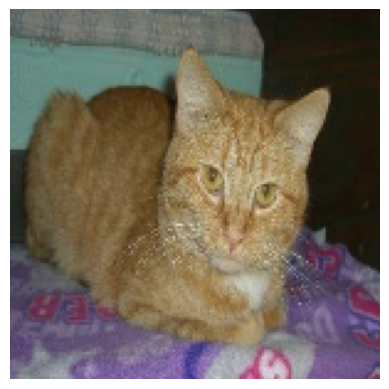

Actual: cat
Predicted: cat
Prediction score: 0.0003316205


In [18]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in test_ds.take(1):
    image = images[0]
    actual_label = labels[0]

    prediction = model.predict(np.expand_dims(image, axis=0))[0][0]

    predicted_class = "dog" if prediction > 0.5 else "cat"
    actual_class = "dog" if actual_label == 1 else "cat"

    plt.imshow(image.numpy().astype("uint8"))
    plt.axis("off")
    plt.show()

    print("Actual:", actual_class)
    print("Predicted:", predicted_class)
    print("Prediction score:", prediction)

## Data Augmentation

In this step, we create a **data augmentation** layer to generate slightly modified versions of the training images.

The model randomly **flips, rotates, and zooms** images during training. This increases the variety of training data and helps the model **generalize better to new images and reduce overfitting**.


In [20]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## Building the Improved CNN Model

In this step, we build an **improved CNN model** by adding **data augmentation** before normalization and feature extraction.

The model applies random **flipping, rotation, and zooming** to training images to increase data variety and help reduce overfitting. The CNN then uses three convolutional layers to extract features, followed by dense layers for **Cat and Dog classification**.

Finally, `model.summary()` displays the complete model architecture and its parameters.


In [21]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Data Augmentation
    data_augmentation,

    # Normalize pixel values
    layers.Rescaling(1./255),

    # CNN layers
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Building the Improved CNN Model

In this step, we improve the CNN model by adding a **Dropout layer** after the first dense layer.

The `Dropout(0.5)` layer randomly disables **50% of the neurons** during training. This helps reduce **overfitting** and improves the model's ability to generalize to new images.

The model also uses **data augmentation**, normalization, convolutional layers, and pooling layers for feature extraction before classifying the image as **Cat or Dog**.


In [22]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)



## Compiling the CNN Model

In this step, we configure the CNN model for training using the `compile()` function.

The **Adam optimizer** is used to update the model's weights, while **binary cross-entropy** is used as the loss function because this is a **binary classification** problem. Accuracy is used as the evaluation metric to measure how many images are classified correctly.



In [24]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Training the CNN Model

In this step, we train the CNN model using the **training dataset** for 10 epochs.

The `validation_data` is used to evaluate the model's performance after each epoch. The training history is stored in `history`, which can later be used to **plot accuracy and loss graphs** and analyze the model's performance.


In [25]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.5619 - loss: 0.6904 - val_accuracy: 0.5828 - val_loss: 0.6783
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 421s 2s/step - accuracy: 0.6049 - loss: 0.6597 - val_accuracy: 0.6406 - val_loss: 0.6370
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 425s 2s/step - accuracy: 0.6547 - loss: 0.6257 - val_accuracy: 0.6792 - val_loss: 0.5995
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 458s 2s/step - accuracy: 0.6948 - loss: 0.5907 - val_accuracy: 0.7227 - val_loss: 0.5649
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.7164 - loss: 0.5642 - val_accuracy: 0.7420 - val_loss: 0.5270
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.7298 - loss: 0.5429 - val_accuracy: 0.7326 - val_loss: 0.5512
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 444s 2s/step - accuracy: 0.7499 - loss: 0.5149 - val_accuracy: 0.7657 - val_loss: 0.4853
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.7604 - loss: 0.4955 - val_accu

## Evaluating Model Performance

After training, we evaluate the model using the test dataset. This gives us the final accuracy and loss on images that were not used for training.

In [26]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 415ms/step - accuracy: 0.7949 - loss: 0.4584
Test Accuracy: 0.7948591113090515


## Saving the Trained Model

After training and evaluating the CNN model, we save the trained model as a `.keras` file.

Saving the model allows us to use the trained CNN later without training it again. The model is saved in Google Drive so that it can be loaded and used for future predictions.

In [27]:
model.save('/content/drive/MyDrive/Datas/cat_dog_model_improved.keras')

## Testing the Model with a Sample Image

In this section, we select an image from the test dataset and use the trained CNN model to predict whether the image contains a cat or a dog.

The prediction score is compared with a threshold of 0.5:
- Score greater than 0.5 → Dog
- Score less than or equal to 0.5 → Cat

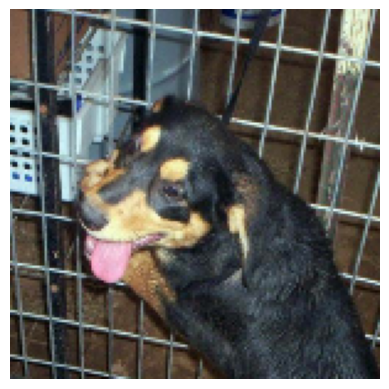

Actual: dog
Predicted: dog
Prediction score: 0.93731916


In [29]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in test_ds.take(1):
    image = images[0]
    actual_label = labels[0]

    prediction = model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )[0][0]

    predicted_class = "dog" if prediction > 0.5 else "cat"
    actual_class = "dog" if actual_label == 1 else "cat"

    plt.imshow(image.numpy().astype("uint8"))
    plt.axis("off")
    plt.show()

    print("Actual:", actual_class)
    print("Predicted:", predicted_class)
    print("Prediction score:", prediction)

## Confusion Matrix

A confusion matrix is used to evaluate the classification performance of the model.

It shows the number of:
- Correctly predicted Cat images
- Incorrectly predicted Cat images
- Correctly predicted Dog images
- Incorrectly predicted Dog images

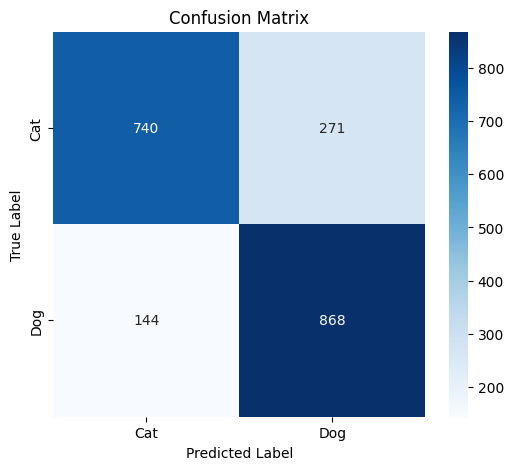

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['Cat', 'Dog']

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Classification Report

The classification report provides precision, recall, F1-score, and support for each class.

These metrics help us understand how well the model performs separately for Cat and Dog images.

In [31]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

              precision    recall  f1-score   support

         Cat       0.84      0.73      0.78      1011
         Dog       0.76      0.86      0.81      1012

    accuracy                           0.79      2023
   macro avg       0.80      0.79      0.79      2023
weighted avg       0.80      0.79      0.79      2023



### Classification Report

The classification report shows the model's performance for each class.

The model achieved an overall **accuracy of 79%** on 2,023 test images. The **Dog class** has a higher recall of **0.86**, while the **Cat class** has a higher precision of **0.84**. The F1-scores of **0.78 for Cat** and **0.81 for Dog** indicate reasonably balanced performance between the two classes.

Overall, the model performs better at identifying **Dogs** than **Cats**.


## Training and Validation Accuracy

This graph shows how the model's **training accuracy** and **validation accuracy** change over the training epochs.

Comparing the two curves helps us understand how well the model learns and whether there are signs of **overfitting or underfitting**.


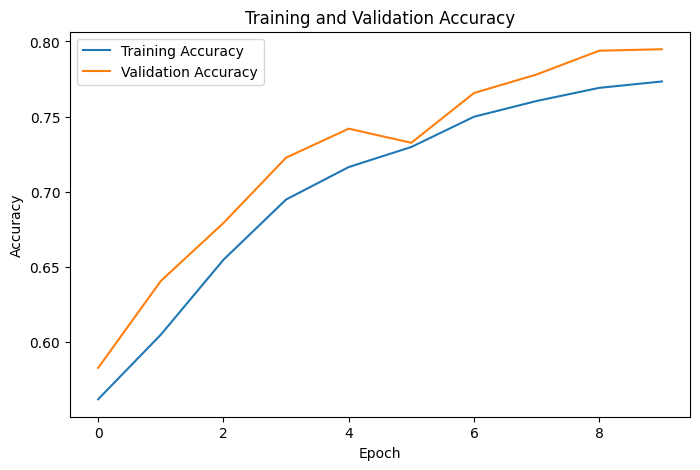

In [32]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

The accuracy graph shows that both training and validation accuracy improved during training. The validation accuracy reached approximately 79.5%, while the training accuracy reached approximately 77.3%. The relatively close performance indicates that data augmentation and dropout helped reduce overfitting.

## Training and Validation Loss

This graph shows how the **training loss** and **validation loss** change over the training epochs.

The loss indicates how much the model's predictions differ from the actual labels. Comparing the training and validation loss helps us understand the model's learning progress and identify possible **overfitting**.


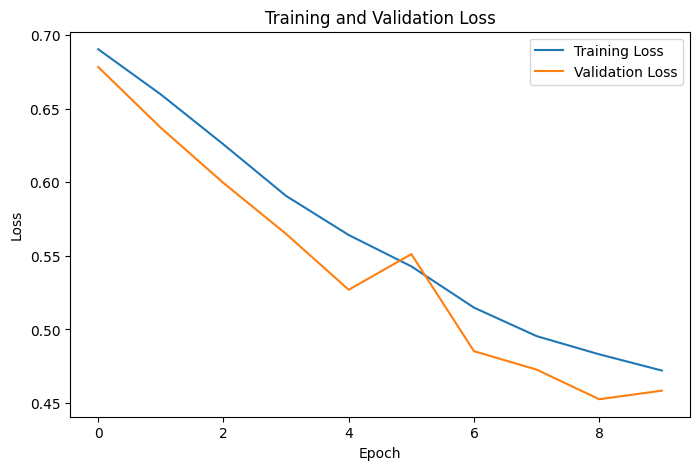

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

The loss graph shows that both training and validation loss decreased during training. This indicates that the model learned effectively. The relatively close training and validation loss values suggest that overfitting was reduced after applying data augmentation and dropout.

### Test with a Dog Image

A new dog image is provided to the trained CNN to check whether the model correctly identifies it as a dog.

In [46]:
img_path ='/content/Test/dog.png'

In [49]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Change target_size to match training size (150, 150)
img = load_img(img_path, target_size=(150, 150))

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction probability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Predicted: Dog ")
else:
    print("Predicted: Cat ")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Prediction probability: 0.974446
Predicted: Dog 


### Result

The model predicts the provided image as **Dog** when the predicted probability is greater than 0.5.

### Test with a Cat Image

A new cat image is provided to the trained CNN to check whether the model correctly identifies it as a cat.

In [51]:
img_path = '/content/Test/cat.jpeg'

In [52]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Change target_size to match training size (150, 150)
img = load_img(img_path, target_size=(150, 150))

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction probability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Predicted: Dog ")
else:
    print("Predicted: Cat ")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Prediction probability: 0.033812314
Predicted: Cat 


### Result

The model predicts the provided image as **Cat** when the predicted probability is 0.5 or below.